# Markowitz Portfolio Optimization 
## Eli Lilly (LLY), TSMC (TSM), Schneider Electric (SU.PA)

this notebook implements the **Modern Portofolio Theory** developed by Harry Markowitz (Nobel Prize 1990)

We use  2 years of real historical data find the optimal allocation between 3 assets that maximizes the **Sharpe Ratio** the best return per unit of risk.


In [7]:
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

tickers = ["LLY", "TSM", "SU.PA"]
data = yf.download(tickers, period="2y")["Close"]
data = data.dropna()

print(f"Data downloaded: {len(data)} trading days")
data.head()

[*********************100%***********************]  3 of 3 completed

Data downloaded: 493 trading days


Ticker,LLY,SU.PA,TSM
Date,,,
2024-09-19,902.403931,230.585602,171.974533
2024-09-20,908.764893,226.523285,169.886093
2024-09-23,905.835938,230.537262,170.549698
2024-09-24,911.664307,232.133179,177.585999
2024-09-25,911.792542,233.245453,177.956848


## Returns and Risk Analysis

In [8]:
returns = data.pct_change().dropna()

ann_returns = returns.mean() * 252
ann_volatility = returns.std() * np.sqrt(252)

print("Annualized Returns:")
print(ann_returns.round(4))
print("\nAnnualized Volatility:")
print(ann_volatility.round(4))

Annualized Returns:
Ticker
LLY      0.1896
SU.PA    0.1570
TSM      0.5414
dtype: float64

Annualized Volatility:
Ticker
LLY      0.3769
SU.PA    0.3427
TSM      0.4163
dtype: float64


## Correlation Analysis

In [9]:
correlation_matrix = returns.corr()
correlation_matrix.round(2)

Ticker,LLY,SU.PA,TSM
Ticker,,,
LLY,1.00,-0.04,0.05
SU.PA,-0.04,1.00,0.48
TSM,0.05,0.48,1.00


## Monte Carlo Simulation — 10,000 Portfolios

In [10]:
cov_matrix = returns.cov() * 252

n_portfolios = 10000
portfolio_returns = []
portfolio_volatilities = []
portfolio_weights = []

for i in range(n_portfolios):
    weights = np.random.random(3)
    weights = weights / np.sum(weights)
    port_return = np.sum(weights * returns.mean() * 252)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    portfolio_returns.append(port_return)
    portfolio_volatilities.append(port_volatility)
    portfolio_weights.append(weights)

print(f"Simulation complete: {n_portfolios} portfolios generated")

Simulation complete: 10000 portfolios generated


## Efficient Frontier

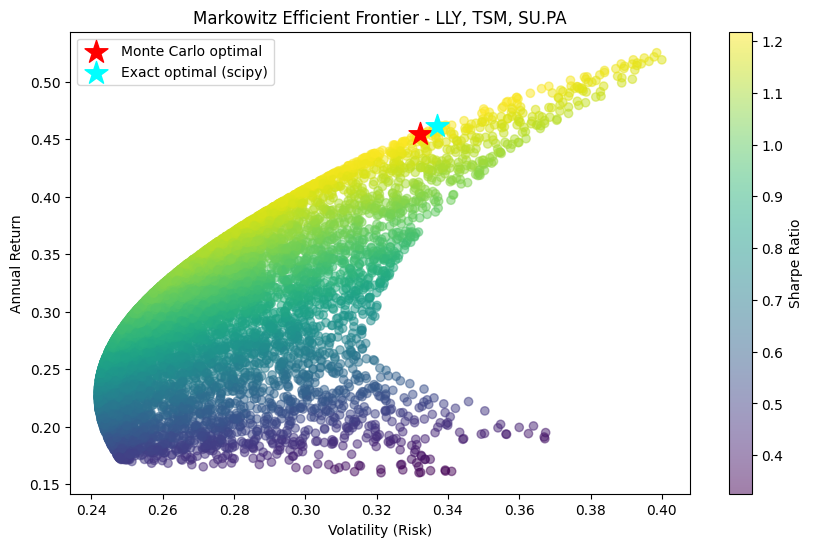

In [11]:
from scipy.optimize import minimize

# Sharpe ratios and Monte Carlo optimal
sharpe_ratios = [(r - 0.05) / v for r, v in zip(portfolio_returns, portfolio_volatilities)]
best_idx = sharpe_ratios.index(max(sharpe_ratios))
best_weights = portfolio_weights[best_idx]

# scipy.optimize — exact optimal portfolio
def neg_sharpe(weights):
    port_return = np.sum(weights * returns.mean() * 252)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -(port_return - 0.05) / port_volatility

constraints = {"type": "eq", "fun": lambda x: np.sum(x) - 1}
bounds = tuple((0, 1) for _ in range(3))
initial_weights = [1/3, 1/3, 1/3]

result = minimize(neg_sharpe, initial_weights, method="SLSQP",bounds=bounds, constraints=constraints)
optimal_weights = result.x

exact_return = np.sum(optimal_weights * returns.mean() * 252)
exact_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))

# Plot everything together
plt.figure(figsize=(10, 6))
scatter = plt.scatter(portfolio_volatilities, portfolio_returns, c=sharpe_ratios, cmap="viridis", alpha=0.5)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.scatter(portfolio_volatilities[best_idx], portfolio_returns[best_idx],color="red", marker="*", s=300, label="Monte Carlo optimal")
plt.scatter(exact_volatility, exact_return,color="cyan", marker="*", s=300, label="Exact optimal (scipy)")
plt.xlabel("Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Markowitz Efficient Frontier - LLY, TSM, SU.PA")
plt.legend()
plt.show()

## Optimal Portfolio

In [12]:
print("Monte Carlo Optimal Portfolio:")
print("-" * 45)
print(f"Eli Lilly:           {best_weights[0]*100:.2f}%")
print(f"TSMC:                {best_weights[1]*100:.2f}%")
print(f"Schneider Electric:  {best_weights[2]*100:.2f}%")
print(f"Expected Return:     {portfolio_returns[best_idx]*100:.2f}%")
print(f"Volatility:          {portfolio_volatilities[best_idx]*100:.2f}%")
print(f"Sharpe Ratio:        {max(sharpe_ratios):.2f}")
print()
print("True Optimal Portfolio (scipy.optimize):")
print("-" * 45)
print(f"Eli Lilly:           {optimal_weights[0]*100:.2f}%")
print(f"TSMC:                {optimal_weights[1]*100:.2f}%")
print(f"Schneider Electric:  {optimal_weights[2]*100:.2f}%")
print(f"Expected Return:     {exact_return*100:.2f}%")
print(f"Volatility:          {exact_volatility*100:.2f}%")
print(f"Sharpe Ratio:        {(-result.fun):.2f}")

Monte Carlo Optimal Portfolio:
---------------------------------------------
Eli Lilly:           23.61%
TSMC:                0.94%
Schneider Electric:  75.45%
Expected Return:     45.47%
Volatility:          33.22%
Sharpe Ratio:        1.22

True Optimal Portfolio (scipy.optimize):
---------------------------------------------
Eli Lilly:           22.75%
TSMC:                0.00%
Schneider Electric:  77.25%
Expected Return:     46.13%
Volatility:          33.70%
Sharpe Ratio:        1.22
